In [240]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib as plb
import cv2
import datasets
import sklearn
import sklearn.svm
from numpy import arange, array, random
from cv2 import imread, imshow, imwrite, resize
from pathlib import Path
from sklearn.linear_model import Lasso, Ridge, RidgeClassifier, SGDRegressor, SGDClassifier, PoissonRegressor, GammaRegressor, HuberRegressor, TweedieRegressor, QuantileRegressor, TheilSenRegressor, PassiveAggressiveRegressor#CV CrossValidation, Just logestic for classification
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, KNeighborsTransformer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingRegressor, AdaBoostRegressor, StackingRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.base import BaseEstimator
from sklearn.datasets import fetch_openml, load_breast_cancer, load_iris, fetch_california_housing, make_blobs
from sklearn.utils import check_array
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, LabelEncoder, OneHotEncoder, Normalizer, StandardScaler, MinMaxScaler, minmax_scale, normalize, label_binarize
from sklearn.model_selection import cross_val_predict, train_test_split, cross_val_score, GridSearchCV#CV CrossValidation
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
from datasets import load_dataset


In [5]:
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\Courses\Programming\Programming docs\Datasets\12col-car-pricing-numerical-dataset\cardekho.csv")

In [ ]:
df
GridSearchCV()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


In [152]:
def cast(x):
    if pd.isna(x): return np.nan
    elif isinstance(x, str) and x.strip() == '': return np.nan
    else: return float(x)

def check_str(x):
    if pd.isna(x): return np.nan
    elif isinstance(x, str) and x.strip() == '': return np.nan
    else: return x

def year_normalizer(x): return (x-min(x))**(27/11)

def selling_price_normalizer(x): return np.log10(x)

def km_driven_normalizer(x): return np.log10(x)**3

def mileage_normalizer(x): return x

def engine_normalizer(x): return x**(1/15)

def max_power_normalizer(x): return x**(5/9)

def seats_normalizer(x): return x


In [8]:
# df['max_power'] = df['max_power'].apply(lambda x : cast(x))
# index = df.loc[(df['max_power'] == -1.)].index
# df = df.drop(index)

In [63]:
categorical_columns_names = df.columns[df.dtypes == 'object'].to_list()[:-1]
numerical_columns_names = df.columns[df.dtypes != 'object'].to_list() + ['max_power']

mean_imputer = SimpleImputer()
mood_imputer = SimpleImputer(strategy='most_frequent')
ohe = OneHotEncoder(handle_unknown='ignore')
standard_scaler = StandardScaler()

In [153]:
#Data preprocessing
pip_year = Pipeline([
    ("SimpleImputer", mean_imputer),
    ('Normalizing', FunctionTransformer(year_normalizer, feature_names_out='one-to-one')),
    ("StandardScaler", standard_scaler)
])

pip_selling_price = Pipeline([
    ("SimpleImputer", mean_imputer),
    ('Normalizing', FunctionTransformer(selling_price_normalizer, feature_names_out='one-to-one')),
    ("StandardScaler", standard_scaler)
])

pip_km_driven = Pipeline([
    ("SimpleImputer", mean_imputer),
    ('Normalizing', FunctionTransformer(km_driven_normalizer, feature_names_out='one-to-one')),
    ("StandardScaler", standard_scaler)
])

pip_mileage = Pipeline([
    ("SimpleImputer", mean_imputer),
    ('Normalizing', FunctionTransformer(mileage_normalizer, feature_names_out='one-to-one')),
    ("StandardScaler", standard_scaler)
])

pip_engine = Pipeline([
    ("SimpleImputer", mean_imputer),
    ('Normalizing', FunctionTransformer(engine_normalizer, feature_names_out='one-to-one')),
    ("StandardScaler", standard_scaler)
])

pip_max_power = Pipeline([
    ('Float Caster', FunctionTransformer(lambda x : x.map(cast), feature_names_out='one-to-one')),#map(dataframe), apply(Series)
    ("SimpleImputer", mean_imputer),
    ('Normalizing', FunctionTransformer(max_power_normalizer, feature_names_out='one-to-one')),
    ("StandardScaler", standard_scaler)
])

pip_seats = Pipeline([
    ("SimpleImputer", mean_imputer),
    ('Normalizing', FunctionTransformer(seats_normalizer, feature_names_out='one-to-one')),
    ("StandardScaler", standard_scaler)
])

pip_categoricals = Pipeline([
    ("String Check", FunctionTransformer(lambda x : x.map(check_str), feature_names_out='one-to-one')),
    ("Mood SimpleImputer", mood_imputer),
    ('OneHotEncoder', ohe)
])


total_transforms = ColumnTransformer([
    ('year Transformation', pip_year, ['year']),
    ('selling_price Transformation', pip_selling_price, ['selling_price']),
    ('km_driven Transformation', pip_km_driven, ['km_driven']),
    ('mileage Transformation', pip_mileage, ['mileage(km/ltr/kg)']),
    ('engine Transformation', pip_engine, ['engine']),
    ('max_power Transformation', pip_max_power, ['max_power']),
    ('seats Transformation', pip_seats, ['seats']),
    ('Categorical Features Transformation', pip_categoricals, categorical_columns_names),
])

data = total_transforms.fit_transform(df)
data_arr = data.toarray()
total_transforms

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('year Transformation', ...), ('selling_price Transformation', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``t

In [154]:
preprocessed_df  = pd.DataFrame(data_arr, columns=total_transforms.get_feature_names_out().tolist())
transformed_numerical_columns_names = preprocessed_df.columns[:7]
numerical_columns_names

['year',
 'selling_price',
 'km_driven',
 'mileage(km/ltr/kg)',
 'engine',
 'seats',
 'max_power']

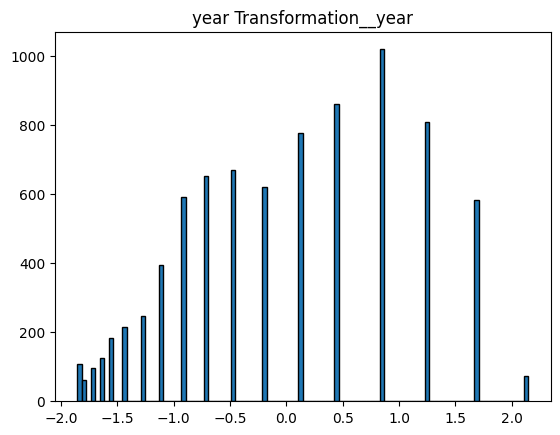

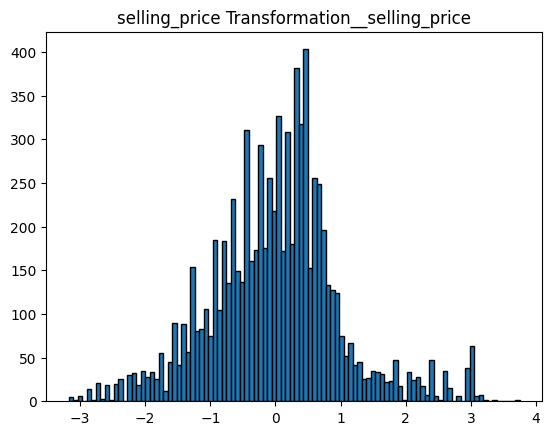

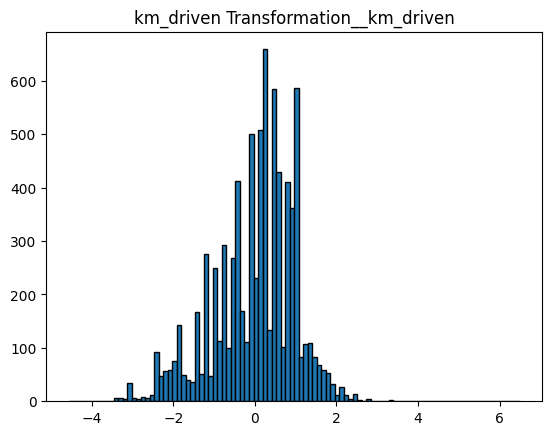

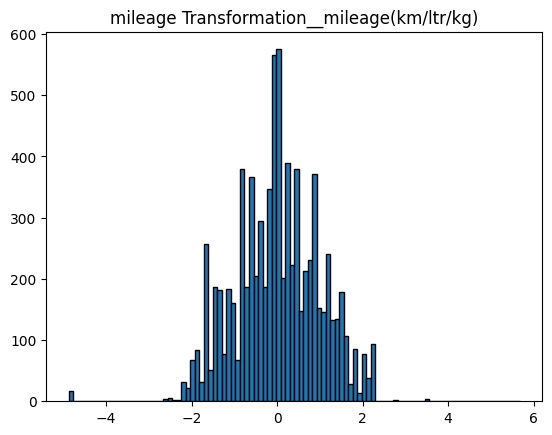

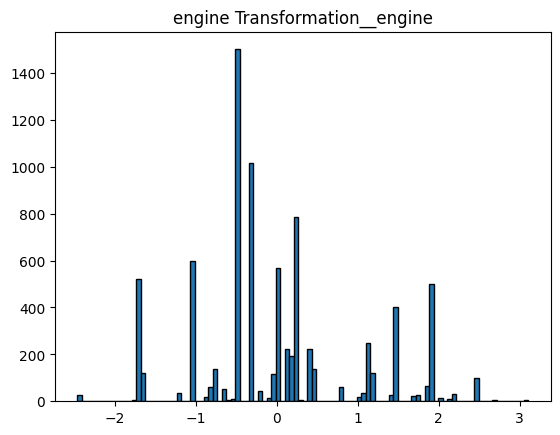

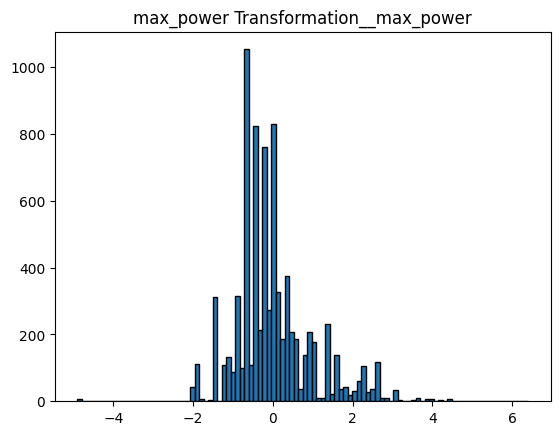

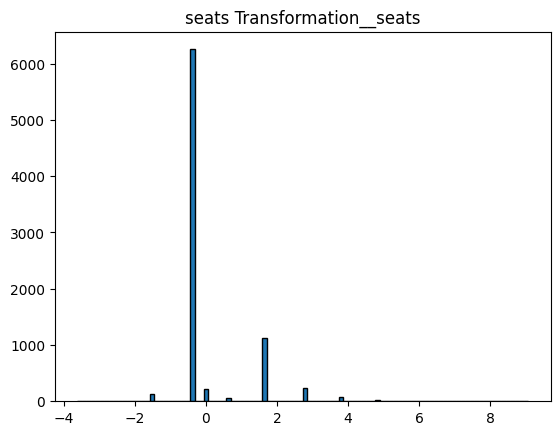

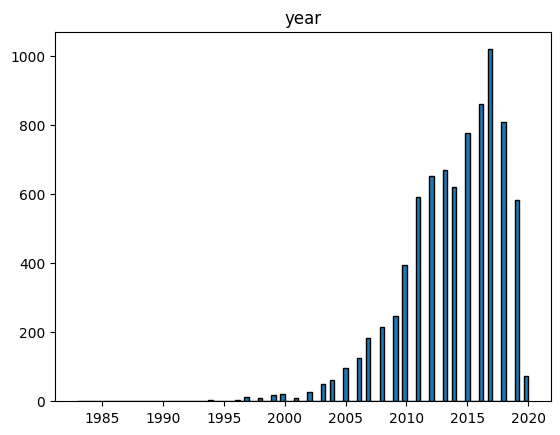

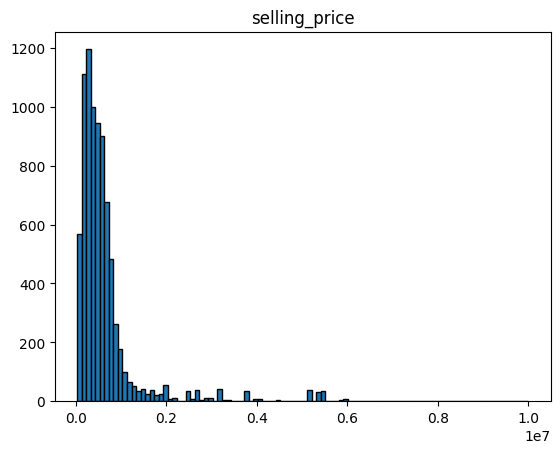

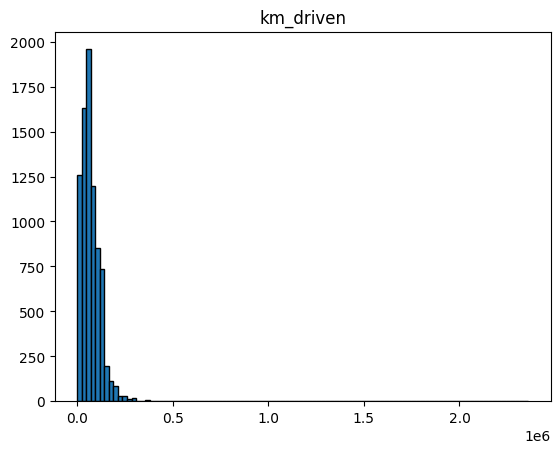

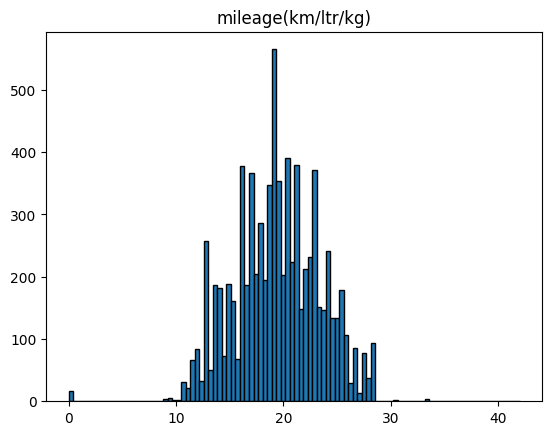

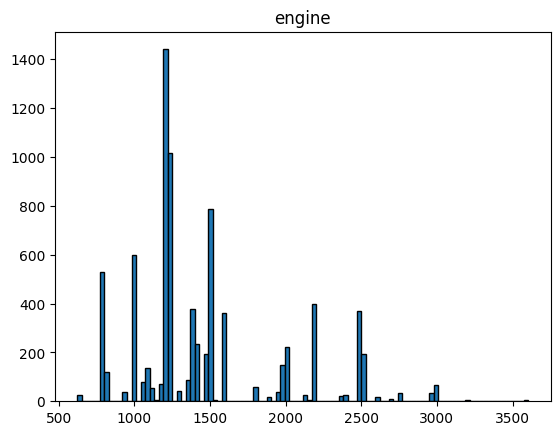

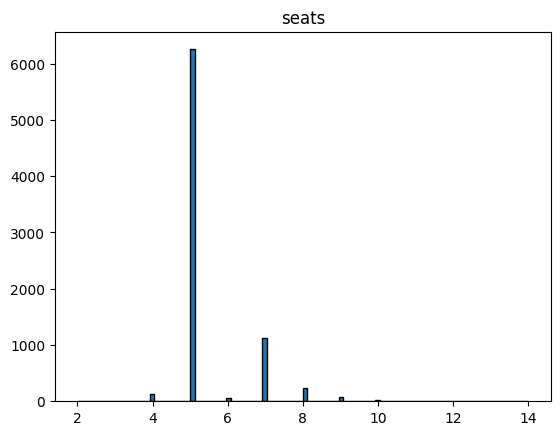

In [124]:
for col in transformed_numerical_columns_names:
    plt.figure(col)
    plt.title(col)
    plt.hist(preprocessed_df[[col]], bins=100, edgecolor='black')
    plt.show()

for col in numerical_columns_names[:-1]:
    plt.figure(col)
    plt.title(col)
    plt.hist(df[col], bins=100, edgecolor='black')
    plt.show()

In [ ]:
#Data Splitting
X_train, X_test, y_train, y_test = train_test_split(preprocessed_df.drop(columns=preprocessed_df.columns[1]), preprocessed_df[preprocessed_df.columns[1]], test_size=0.15)

In [250]:
#Training mode for estimator

#Evaluating
# model.score

#Saving model

#Predicting

In [247]:
# Lasso, Ridge, RidgeClassifier, SGDRegressor, SGDClassifier, PoissonRegressor, GammaRegressor, HuberRegressor, TweedieRegressor, QuantileRegressor, TheilSenRegressor, RANSACRegressorm, PassiveAggressiveRegressor
lgr = BaggingRegressor(n_estimators=100)
lgr.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [ ]:
scr = lgr.score(X_test, y_test)

0.935325765260284